<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/SVM/Support_Vector_Machines_(SVM)_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Support Vector Machines (SVM)-Scratch

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load data
iris = load_iris()
X, y = iris.data, iris.target

# SVM is binary by nature, so let's simplify to 'Versicolor' vs 'Virginica'
# We'll filter out class 0 (Setosa)
mask = y != 0
X, y = X[mask], y[mask]
# Map classes to -1 and 1 (Standard for SVM math)
y = np.where(y == 1, -1, 1)

# 2. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data Processing

In [ ]:
class SVMScratch:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iterations=1000):
        self.lr = lr
        self.lambda_param = lambda_param # Regularization (C parameter)
        self.n_iterations = n_iterations
        self.w = None
        self.b = None

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                # Condition: y_i * (w * x_i - b) >= 1
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # Only apply regularization penalty
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Apply penalty + misclassification error
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

SVM Class

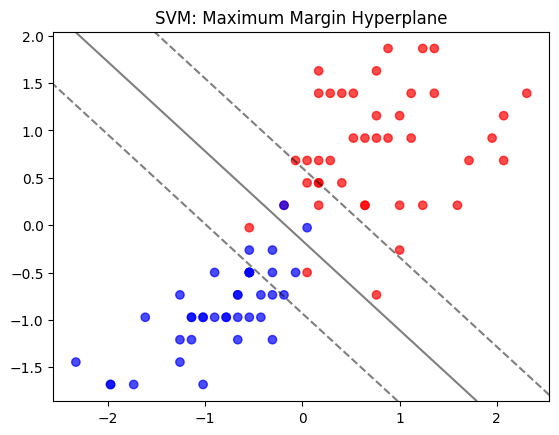

In [ ]:
import matplotlib.pyplot as plt

# Using Petal Length and Petal Width
X_v = X_train_scaled[:, 2:4]
svm = SVMScratch()
svm.fit(X_v, y_train)

def plot_svm(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7)
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to plot boundary
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = (np.dot(xy, model.w) - model.b).reshape(XX.shape)

    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title("SVM: Maximum Margin Hyperplane")
    plt.show()

plot_svm(X_v, y_train, svm)

2D Visualization

In [ ]:
import plotly.graph_objects as go

# Create non-linear circular data conceptually
z = X_v[:, 0]**2 + X_v[:, 1]**2  # Radial basis function style projection

fig = go.Figure(data=[
    go.Scatter3d(x=X_v[:, 0], y=X_v[:, 1], z=z, mode='markers',
                 marker=dict(color=y_train, colorscale='Viridis', size=5))
])

fig.update_layout(title="SVM Kernel Trick: Projecting to 3D for Separability",
                  scene=dict(xaxis_title='X1', yaxis_title='X2', zaxis_title='X1^2 + X2^2'))
fig.show()

3D Visualization